In [1]:
import os
import shutil
import tempfile
import time
import matplotlib.pyplot as plt
# from monai.apps import DecathlonDataset
from monai.config import print_config
from monai.data import CacheDataset, DataLoader, Dataset, decollate_batch
from monai.handlers.utils import from_engine
from monai.losses import DiceLoss
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric, MeanIoU
from monai.networks.nets import UNet
from monai.transforms import (
    AsDiscrete,
    AsDiscreted,
    EnsureChannelFirstd,
    Compose,
    CropForegroundd,
    LoadImaged,
    Orientationd,
    RandCropByPosNegLabeld,
    SaveImaged,
    ScaleIntensityRanged,
    Spacingd,
    Invertd,
    MapTransform,
    SpatialPadd,
    ResizeWithPadOrCropd

)
from monai.utils import set_determinism, first
from monai.networks.layers import Norm
from tqdm import tqdm
import glob
import torch

print_config()


/home/bio-21/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MONAI version: 1.5.1
Numpy version: 2.2.4
Pytorch version: 2.8.0+cu128
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 9c6d819f97e37f36c72f3bdfad676b455bd2fa0d
MONAI __file__: /home/<username>/projects/miniconda3/envs/MONAI/lib/python3.10/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.4.11
ITK version: 5.4.4
Nibabel version: 5.3.2
scikit-image version: 0.25.2
scipy version: 1.15.3
Pillow version: 11.3.0
Tensorboard version: 2.20.0
gdown version: 5.2.0
TorchVision version: 0.23.0+cu128
tqdm version: 4.67.1
lmdb version: 1.7.3
psutil version: 5.9.1
pandas version: 2.3.3
einops version: 0.8.1
transformers version: 4.40.2
mlflow version: 3.4.0
pynrrd version: 1.1.3
clearml version: 2.0.3rc0

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.html#installing-the-recommended-dependencies



In [ ]:
data_dir = "TCGA-NIFTI/TCGA-BRCA/"
train_images = sorted(glob.glob(os.path.join(data_dir, "TCGA-AO-A0J8", "**","**", "*.nii.gz"), recursive=True), key=lambda x : int(x.split("-")[-1].split(".")[0]))
# train_labels = sorted(glob.glob(os.path.join(data_dir, "label", "*.nii")), key=lambda x : int(x.split("-")[-1].split(".")[0]))
# files = [f for f in train_images if os.path.isfile(f)]
train_images

['test-cxx/R027596_sxx-_(ct7).nii.gz',
 'test-cxx/R027596_sxx-_(ct7)a.nii.gz',
 'test-cxx/R027596_sxx-_(ct7)b.nii.gz']

In [3]:
set_determinism(seed=42)

In [17]:
# data_dicts = [{"image": image_name, "label": label_name} for image_name, label_name in zip(train_images, train_labels)]
data_dicts = [{"image": image_name} for image_name in train_images]
# train_files, test_files, val_files = data_dicts[0:91], data_dicts[91:110], data_dicts[110:130]
len(data_dicts)

1884

In [18]:
import random
random.seed(42)
random.shuffle(data_dicts)
train_files, test_files, val_files = data_dicts[0:91], data_dicts[91:110], data_dicts[110:130]

In [19]:
train_files

[{'image': 'manifest-1747287301493/TCGA-BRCA/TCGA-AO-A0J8/1.3.6.1.4.1.14519.5.2.1.9203.4002.208016093835871626569130554853/1.3.6.1.4.1.14519.5.2.1.9203.4002.171454502691423652605932537726/1-14.dcm'},
 {'image': 'manifest-1747287301493/TCGA-BRCA/TCGA-AO-A0J8/1.3.6.1.4.1.14519.5.2.1.9203.4002.208016093835871626569130554853/1.3.6.1.4.1.14519.5.2.1.9203.4002.332176682859864127607877935263/1-070.dcm'},
 {'image': 'manifest-1747287301493/TCGA-BRCA/TCGA-AO-A0J8/1.3.6.1.4.1.14519.5.2.1.9203.4002.208016093835871626569130554853/1.3.6.1.4.1.14519.5.2.1.9203.4002.233660357561268980225119206021/1-110.dcm'},
 {'image': 'manifest-1747287301493/TCGA-BRCA/TCGA-AO-A0J8/1.3.6.1.4.1.14519.5.2.1.9203.4002.208016093835871626569130554853/1.3.6.1.4.1.14519.5.2.1.9203.4002.558588012848805796274633643124/1-06.dcm'},
 {'image': 'manifest-1747287301493/TCGA-BRCA/TCGA-AO-A0J8/1.3.6.1.4.1.14519.5.2.1.9203.4002.208016093835871626569130554853/1.3.6.1.4.1.14519.5.2.1.9203.4002.121555874102630636414210864777/1-30.dcm'}

In [7]:
class ConvertToMultiChannelBasedOnClassesd(MapTransform):
    """
    Convert labels to multi channels based on brats classes:
    label 1 is the peritumoral edema
    label 2 is the GD-enhancing tumor
    label 3 is the necrotic and non-enhancing tumor core
    The possible classes are TC (Tumor core), WT (Whole tumor)
    and ET (Enhancing tumor).

    """

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            result = []
            # merge label 2 and label 3 to construct TC
            result.append(torch.logical_or(d[key] == 1, d[key] == 2))
            # merge labels 1, 2 and 3 to construct WT
            # result.append(torch.logical_or(torch.logical_or(d[key] == 2, d[key] == 3), d[key] == 1))
            # label 2 is ET
            result.append(d[key] == 2)
            d[key] = torch.stack(result, axis=0).float()
        return d

In [8]:
# from torch.utils.data import random_split

# # dataset = data_dicts  # your MONAI Dataset or any PyTorch Dataset
# total_len = len(data_dicts)
# train_size = int(0.7 * total_len)
# test_size   = int(0.15 * total_len) 
# val_size = total_len - train_size - test_size

# train_ds, val_ds, test_ds = random_split(data_dicts, [train_size, test_size ,val_size])

In [6]:
class DebugShaped(MapTransform):
    def __call__(self, data):
        for key in self.keys:
            print(f"{key} shape: {data[key].shape}")
        return data

train_transforms = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        # EnsureTyped(keys=["image", "label"]),
        # ConvertToMultiChannelBasedOnClassesd(keys="label"),
        ScaleIntensityRanged(
            keys=["image"],
            a_min=-57,
            a_max=164,
            b_min=0.0,
            b_max=1.0,
            clip=True,
        ),
        CropForegroundd(keys=["image", "label"], source_key="image", allow_smaller=True),
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear", "nearest")),
        ResizeWithPadOrCropd(keys=["image","label"], spatial_size=(384, 384, 384)),
        # SpatialPadd(keys=["image", "label"], spatial_size=(96, 96, 96)),
        # DebugShaped(keys=["image", "label"]),
        RandCropByPosNegLabeld(
            keys=["image", "label"],
            label_key="label",
            spatial_size=(128, 128, 48),
            pos=1,
            neg=1,
            num_samples=8,
            image_key="image",
            image_threshold=0,
        ),
        
        # user can also add other random transforms
        # RandAffined(
        #     keys=['image', 'label'],
        #     mode=('bilinear', 'nearest'),
        #     prob=1.0, spatial_size=(96, 96, 96),
        #     rotate_range=(0, 0, np.pi/15),
        #     scale_range=(0.1, 0.1, 0.1)),
    ]
)
val_transforms = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        ScaleIntensityRanged(
            keys=["image"],
            a_min=-57,
            a_max=164,
            b_min=0.0,
            b_max=1.0,
            clip=True,
        ),
        
        
       
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear", "nearest")),
        CropForegroundd(keys=["image", "label"], source_key="image", allow_smaller=True),
        ResizeWithPadOrCropd(keys=["image","label"], spatial_size=(384, 384, 384))
    ]
)

monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


In [35]:
# class DebugShaped(MapTransform):
#     def __call__(self, data):
#         for key in self.keys:
#             print(f"{key} shape: {data[key].shape}")
#         return data

# train_transforms = Compose(
#     [
#         LoadImaged(keys=["image"]),
#         EnsureChannelFirstd(keys=["image"]),
#         # EnsureTyped(keys=["image", "label"]),
#         # ConvertToMultiChannelBasedOnClassesd(keys="label"),
#         ScaleIntensityRanged(
#             keys=["image"],
#             a_min=-57,
#             a_max=164,
#             b_min=0.0,
#             b_max=1.0,
#             clip=True,
#         ),
#         CropForegroundd(keys=["image"], source_key="image", allow_smaller=True),
#         Orientationd(keys=["image"], axcodes="RAS"),
#         Spacingd(keys=["image"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear")),
#         ResizeWithPadOrCropd(keys=["image"], spatial_size=(384, 384, 384)),
#         # SpatialPadd(keys=["image", "label"], spatial_size=(96, 96, 96)),
#         # DebugShaped(keys=["image", "label"]),
#         RandCropByPosNegLabeld(
#             keys=["image"],
#             # label_key="label",
#             spatial_size=(128, 128, 48),
#             pos=1,
#             neg=1,
#             num_samples=8,
#             image_key="image",
#             image_threshold=0,
#         ),
        
#         # user can also add other random transforms
#         # RandAffined(
#         #     keys=['image', 'label'],
#         #     mode=('bilinear', 'nearest'),
#         #     prob=1.0, spatial_size=(96, 96, 96),
#         #     rotate_range=(0, 0, np.pi/15),
#         #     scale_range=(0.1, 0.1, 0.1)),
#     ]
# )
val_transforms = Compose(
    [
        LoadImaged(keys=["image"]),
        EnsureChannelFirstd(keys=["image"]),
        # ScaleIntensityRanged(
        #     keys=["image"],
        #     a_min=-57,
        #     a_max=164,
        #     b_min=0.0,
        #     b_max=1.0,
        #     clip=True,
        # ),
        
        
       
        # Orientationd(keys=["image"], axcodes="RAS"),
        # Spacingd(keys=["image"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear")),
        # CropForegroundd(keys=["image"], source_key="image", allow_smaller=True),
        # ResizeWithPadOrCropd(keys=["image"], spatial_size=(384, 384, 384))
    ]
)

In [36]:
from itertools import islice
check_ds = Dataset(data=train_files, transform=val_transforms)
check_loader = DataLoader(check_ds, batch_size=1)
check_data = first(check_loader)

    

# nth_item = next(check_loader) 


In [27]:
type(check_loader)

monai.data.dataloader.DataLoader

In [30]:
len(check_loader)

91

In [47]:
j = 0
k = 0
for ele in check_loader:
    # print(i)
    # print(type(i))
    for j in range(48):
        print(f"{ ele['label'][0][0][:,:,j].max()} {k}")
        # print(f"{i["label"][0][0][:,:,j].max()} {k}") 

    k+=1
    # break

  1%|          | 1/91 [00:05<07:55,  5.28s/it]

1.0 0
1.0 0
2.0 0
2.0 0
2.0 0
2.0 0
2.0 0
2.0 0
2.0 0
2.0 0
2.0 0
2.0 0
2.0 0
2.0 0
2.0 0
2.0 0
2.0 0
2.0 0
2.0 0
2.0 0
2.0 0
2.0 0
2.0 0
2.0 0
2.0 0
2.0 0
2.0 0
2.0 0
2.0 0
2.0 0
2.0 0
2.0 0
2.0 0
2.0 0
2.0 0
2.0 0
1.0 0
1.0 0
1.0 0
1.0 0
1.0 0
1.0 0
1.0 0
1.0 0
1.0 0
1.0 0
1.0 0
1.0 0


  1%|          | 1/91 [00:10<16:17, 10.86s/it]


KeyboardInterrupt: 

In [40]:
j = 0
for i in check_loader:
    if j == 2:
        check_data=i
        break
    j+=1

image shape: torch.Size([512, 512, 1])


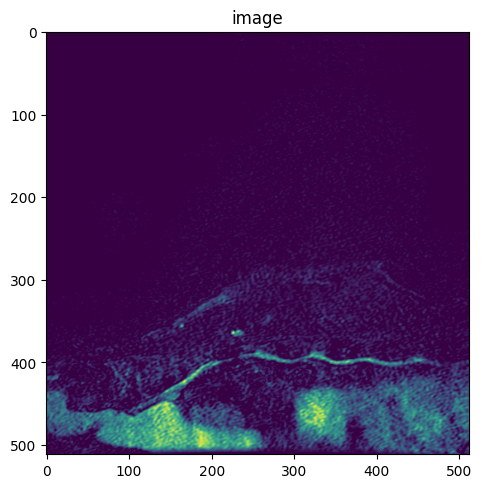

metatensor([[[  0.],
         [  0.],
         [  0.],
         ...,
         [  0.],
         [  0.],
         [  0.]],

        [[  0.],
         [  0.],
         [  0.],
         ...,
         [  0.],
         [  0.],
         [  0.]],

        [[  0.],
         [  0.],
         [  0.],
         ...,
         [  0.],
         [  0.],
         [  0.]],

        ...,

        [[  0.],
         [  0.],
         [ 97.],
         ...,
         [432.],
         [375.],
         [359.]],

        [[  0.],
         [  0.],
         [ 78.],
         ...,
         [299.],
         [313.],
         [287.]],

        [[  0.],
         [  0.],
         [ 81.],
         ...,
         [228.],
         [404.],
         [329.]]])

In [40]:
# check_data = first(check_loader)
image = check_data["image"][0][0]
print(f"image shape: {image.shape}")
# plot the slice [:, :, 80]
plt.figure("check", (12, 6))
plt.subplot(1, 2, 1)
plt.title("image")
plt.imshow(image[:, :])
plt.imshow(image[:, :],cmap="grey",alpha=0.2)
plt.show()
image

image shape: torch.Size([128, 128, 48]), label shape: torch.Size([128, 128, 48])


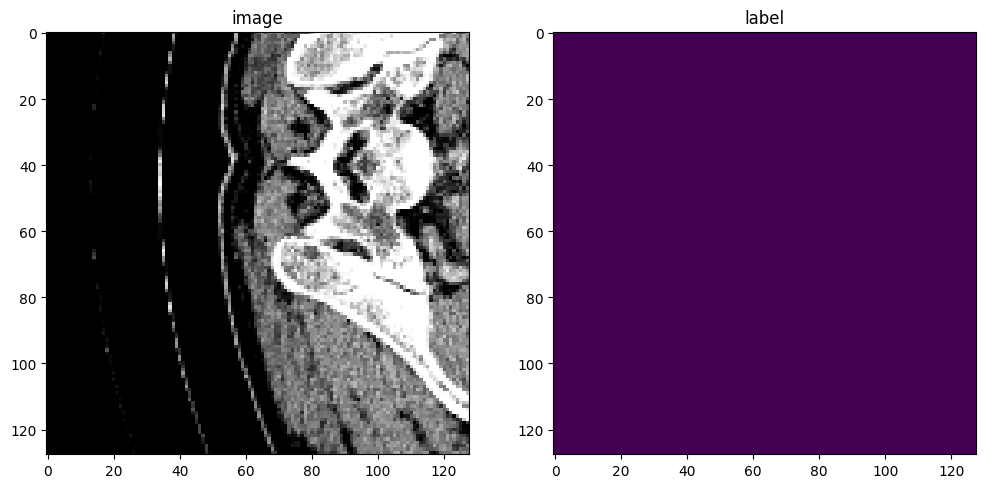

In [8]:
# check_data = first(check_loader)
image, label = (check_data["image"][0][0], check_data["label"][0][0])
print(f"image shape: {image.shape}, label shape: {label.shape}")
# plot the slice [:, :, 80]
plt.figure("check", (12, 6))
plt.subplot(1, 2, 1)
plt.title("image")
plt.imshow(image[:, :, 40], cmap="gray")
plt.subplot(1, 2, 2)
plt.title("label")
plt.imshow(label[:, :, 40])
plt.show()

In [ ]:
# image, label = (check_data["image"][0][0], check_data["label"][0][0])
# i = 0
# for l in label:
#     print(f"{label[:,:,i].max()} {i}")
#     i+=1

0.0 0
0.0 1
0.0 2
0.0 3
0.0 4
0.0 5
0.0 6
0.0 7
0.0 8
0.0 9
0.0 10
0.0 11
0.0 12
0.0 13
0.0 14
0.0 15
0.0 16
0.0 17
0.0 18
0.0 19
0.0 20
0.0 21
0.0 22
0.0 23
0.0 24
0.0 25
0.0 26
0.0 27
0.0 28
0.0 29
0.0 30
0.0 31
0.0 32
0.0 33
0.0 34
0.0 35
0.0 36
0.0 37
0.0 38
0.0 39
0.0 40
0.0 41
0.0 42
0.0 43
0.0 44
0.0 45
0.0 46
0.0 47


IndexError: index 48 is out of bounds for dimension 2 with size 48

In [9]:
train_ds = CacheDataset(data=train_files, transform=train_transforms, cache_rate=1.0, num_workers=16)
# train_ds = Dataset(data=train_files, transform=train_transforms)

# use batch_size=2 to load images and use RandCropByPosNegLabeld
# to generate 2 x 4 images for network training
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=16)

test_ds = CacheDataset(data=test_files, transform=val_transforms, cache_rate=1.0, num_workers=16)
# val_ds = Dataset(data=val_files, transform=val_transforms)
test_loader = DataLoader(test_ds, batch_size=1, num_workers=16)

val_ds = CacheDataset(data=val_files, transform=val_transforms, cache_rate=1.0, num_workers=16)
# val_ds = Dataset(data=val_files, transform=val_transforms)
val_loader = DataLoader(val_ds, batch_size=1, num_workers=16)

Loading dataset:   0%|          | 0/91 [00:00<?, ?it/s]

Loading dataset: 100%|██████████| 20/20 [00:29<00:00,  1.45s/it]


In [10]:
# image = sample["image"][0]
image, label = (check_data["image"][0][0], check_data["label"][0][0])
print(image.min().item(), image.max().item()) 

0.0 1.0


In [19]:
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter(log_dir="runs/segmentation_experiment")

In [11]:
# standard PyTorch program style: create UNet, DiceLoss and Adam optimizer
device = torch.device("cuda:0")
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=3,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
    norm=Norm.BATCH,
).to(device)
loss_function = DiceLoss(to_onehot_y=True, softmax=True)
optimizer = torch.optim.Adam(model.parameters(), 1e-4)
dice_metric = DiceMetric(include_background=False, reduction="mean")
IoU_metric = MeanIoU(include_background=False, reduction="mean")
class_IoU = MeanIoU(include_background=True, reduction="none")

In [52]:
# Model_dir = "Models"
# if not os.path.exists(Model_dir):
#     os.mkdir(Model_dir)

max_epochs = 1000
val_interval = 2
best_dice = -1
best_IoU = -1
best_metric_epoch = -1
epoch_loss_values = []
dice_values = []
IoU_values = []
post_pred = Compose([AsDiscrete(argmax=True, to_onehot=3)])
post_label = Compose([AsDiscrete(to_onehot=3)])

for epoch in range(max_epochs):
    print("training"+"-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0
    for batch_data in train_loader:
        step += 1
        
        inputs, labels = (
            batch_data["image"].to(device),
            batch_data["label"].to(device),
        )
        # print(f"input shape: {inputs.shape}")
        # print(f"label shape: {labels.shape}")
        optimizer.zero_grad()
        outputs = model(inputs)
        # print(f"out shape: {outputs.shape}")
        # print(f"label shape: {labels.shape}")
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        print(f"{step}/{len(train_ds) // train_loader.batch_size}, " f"train_loss: {loss.item():.4f}")
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")

    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            for val_data in val_loader:
                val_inputs, val_labels = (
                    val_data["image"].to(device),
                    val_data["label"].to(device),
                )
                roi_size = (96, 96, 96)
                sw_batch_size = 4
                val_outputs = sliding_window_inference(val_inputs, roi_size, sw_batch_size, model)
                # print(f"val out before: {val_outputs.shape}")
                val_outputs = [post_pred(i) for i in decollate_batch(val_outputs)]
                val_labels = [post_label(i) for i in decollate_batch(val_labels)]
                # print(f"val out:{val_outputs[0].shape}")
                # print(f"val label: {val_labels[0].shape}")
                # compute metric for current iteration
                dice_metric(y_pred=val_outputs, y=val_labels)
                # print("yes")
                IoU_metric(y_pred=val_outputs, y=val_labels)

            # aggregate the final mean dice result
            dice = dice_metric.aggregate().item()
            IoU = IoU_metric.aggregate().item()
            # reset the status for next validation round
            dice_metric.reset()
            IoU_metric.reset()

            dice_values.append(dice)
            IoU_values.append(IoU)

            if dice >= best_dice and IoU >= best_IoU:
                best_dice = dice
                best_IoU = IoU
                best_metric_epoch = epoch + 1
                
                torch.save(model.state_dict(), os.path.join("Models", f"best_metric_model_{IoU:.3f}iou_{dice:.3f}dice.pth"))
                print("saved new best metric model")
            print(
                f"current epoch: {epoch + 1} current mean dice: {dice:.4f} current mean IoU: {IoU:.4f}"
                f"\nbest mean dice: {best_dice:.4f} "
                f"\nbest mean IoU: {best_IoU:.4f} "
                f"at epoch: {best_metric_epoch}"
            )

training----------
epoch 1/1000


input shape: torch.Size([32, 1, 128, 128, 48])
label shape: torch.Size([32, 1, 128, 128, 48])
out shape: torch.Size([32, 3, 128, 128, 48])
label shape: torch.Size([32, 1, 128, 128, 48])
1/22, train_loss: 0.7961
input shape: torch.Size([32, 1, 128, 128, 48])
label shape: torch.Size([32, 1, 128, 128, 48])
out shape: torch.Size([32, 3, 128, 128, 48])
label shape: torch.Size([32, 1, 128, 128, 48])
2/22, train_loss: 0.8132
input shape: torch.Size([32, 1, 128, 128, 48])
label shape: torch.Size([32, 1, 128, 128, 48])
out shape: torch.Size([32, 3, 128, 128, 48])
label shape: torch.Size([32, 1, 128, 128, 48])
3/22, train_loss: 0.8115
input shape: torch.Size([32, 1, 128, 128, 48])
label shape: torch.Size([32, 1, 128, 128, 48])
out shape: torch.Size([32, 3, 128, 128, 48])
label shape: torch.Size([32, 1, 128, 128, 48])
4/22, train_loss: 0.7893
input shape: torch.Size([32, 1, 128, 128, 48])
label shape: torch.Size([32, 1, 128, 128, 48])
out shape: torch.Size([32, 3, 128, 128, 48])
label shape: torc

Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)


val out before: torch.Size([1, 3, 259, 208, 230])
val out:torch.Size([3, 259, 208, 230])
val label: torch.Size([3, 259, 208, 230])
val out before: torch.Size([1, 3, 310, 275, 86])
val out:torch.Size([3, 310, 275, 86])
val label: torch.Size([3, 310, 275, 86])
val out before: torch.Size([1, 3, 253, 202, 302])
val out:torch.Size([3, 253, 202, 302])
val label: torch.Size([3, 253, 202, 302])
val out before: torch.Size([1, 3, 255, 239, 320])
val out:torch.Size([3, 255, 239, 320])
val label: torch.Size([3, 255, 239, 320])
val out before: torch.Size([1, 3, 237, 234, 268])
val out:torch.Size([3, 237, 234, 268])
val label: torch.Size([3, 237, 234, 268])
val out before: torch.Size([1, 3, 304, 242, 337])
val out:torch.Size([3, 304, 242, 337])
val label: torch.Size([3, 304, 242, 337])
val out before: torch.Size([1, 3, 272, 222, 238])
val out:torch.Size([3, 272, 222, 238])
val label: torch.Size([3, 272, 222, 238])
val out before: torch.Size([1, 3, 259, 209, 221])
val out:torch.Size([3, 259, 209, 221

In [1]:
plt.figure("train", (12, 6))
plt.subplot(1, 2, 1)
plt.title("Epoch Average Loss")
x = [i + 1 for i in range(len(epoch_loss_values))]
y = epoch_loss_values
plt.xlabel("epoch")
plt.plot(x, y)
plt.subplot(1, 2, 2)

plt.title("Val Mean Dice")
x = [val_interval * (i + 1) for i in range(len(dice_values))]
y = dice_values
plt.xlabel("epoch")
plt.plot(x, y)
plt.show()

plt.title("Val Mean IoU")
x = [val_interval * (i + 1) for i in range(len(IoU_values))]
y = IoU_values
plt.xlabel("epoch")
plt.plot(x, y)
plt.show()

NameError: name 'plt' is not defined

torch.Size([1, 1, 384, 384, 384])
torch.Size([1, 1, 384, 384, 384])


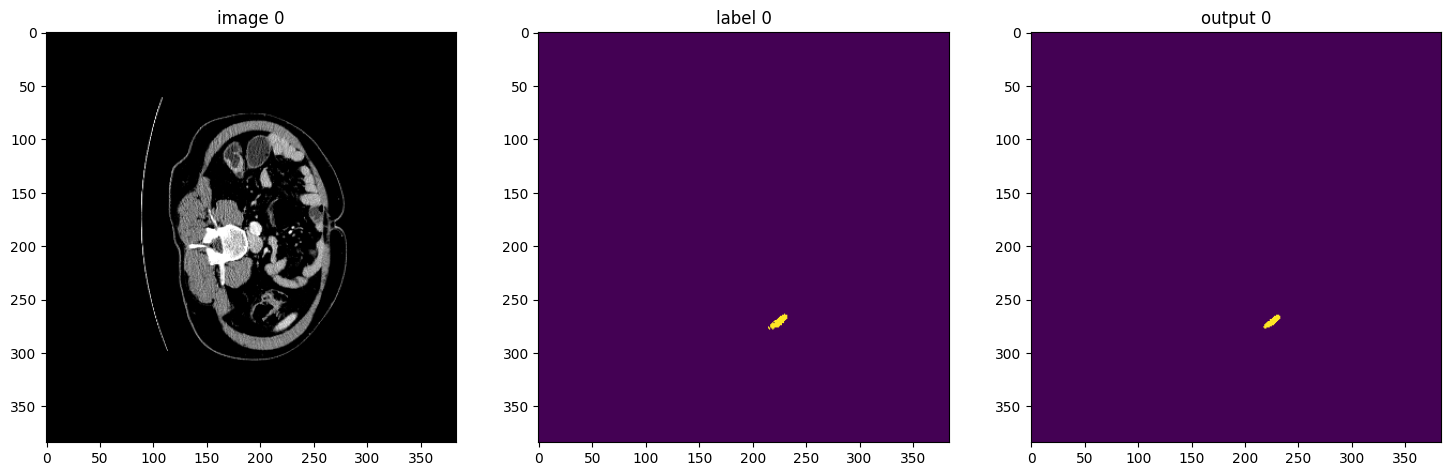

torch.Size([1, 1, 384, 384, 384])
torch.Size([1, 1, 384, 384, 384])


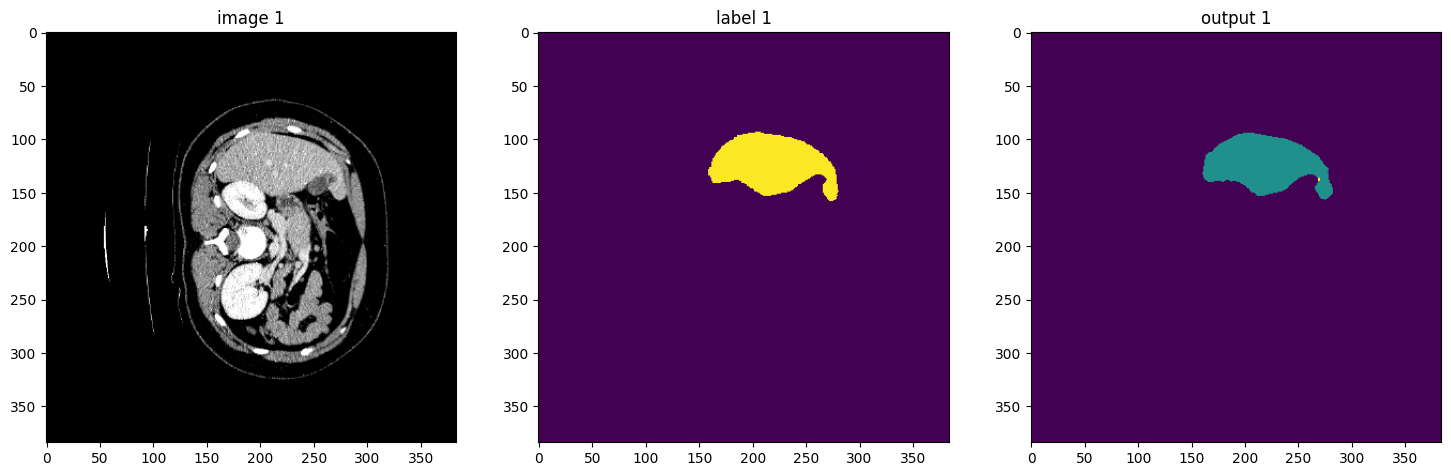

torch.Size([1, 1, 384, 384, 384])
torch.Size([1, 1, 384, 384, 384])


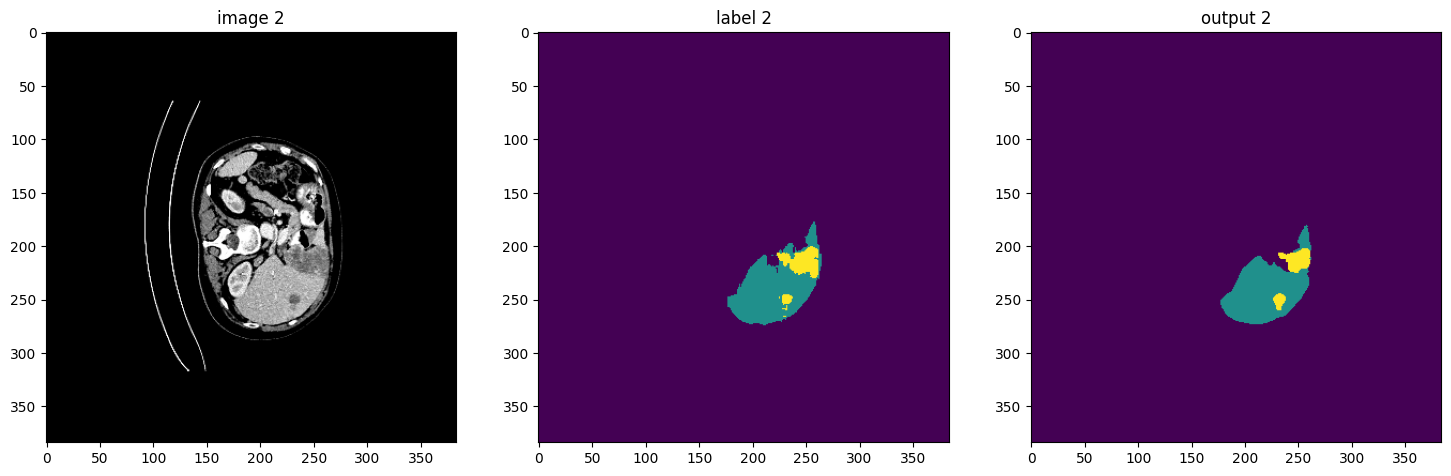

In [19]:
model.load_state_dict(torch.load(os.path.join("Models", "best_metric_model_0.699iou_0.781dice.pth"), weights_only=True))
model.eval()
with torch.no_grad():
    for i, val_data in enumerate(val_loader):
        roi_size = (96,96,96)
        sw_batch_size = 4
        val_outputs = sliding_window_inference(val_data["image"].to(device), roi_size, sw_batch_size, model)
        print(val_data["image"].shape)
        print(val_data["label"].shape)
        # plot the slice [:, :, 80]
        plt.figure("check", (18, 6))
        plt.subplot(1, 3, 1)
        plt.title(f"image {i}")
        plt.imshow(val_data["image"][0, 0, :, :, 192], cmap="gray")
        plt.subplot(1, 3, 2)
        plt.title(f"label {i}")
        plt.imshow(val_data["label"][0, 0, :, :, 192])
        plt.subplot(1, 3, 3)
        plt.title(f"output {i}")
        plt.imshow(torch.argmax(val_outputs, dim=1).detach().cpu()[0, :, :, 192])
        plt.show()
        if i == 2:
            break

In [26]:
from monai.networks.nets import seresnet50
from monai.visualize import GradCAM

model_2d = seresnet50(spatial_dims=2, in_channels=3, num_classes=4)

In [40]:
model

UNet(
  (model): Sequential(
    (0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
          (adn): ADN(
            (N): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (adn): ADN(
            (N): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
      )
      (residual): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    )
    (1): SkipConnection(
      (submodule): Sequential(
        (0): ResidualUnit(
          (conv): Sequential(


In [31]:
for name, _ in model.named_modules(): print(name)


model
model.0
model.0.conv
model.0.conv.unit0
model.0.conv.unit0.conv
model.0.conv.unit0.adn
model.0.conv.unit0.adn.N
model.0.conv.unit0.adn.D
model.0.conv.unit0.adn.A
model.0.conv.unit1
model.0.conv.unit1.conv
model.0.conv.unit1.adn
model.0.conv.unit1.adn.N
model.0.conv.unit1.adn.D
model.0.conv.unit1.adn.A
model.0.residual
model.1
model.1.submodule
model.1.submodule.0
model.1.submodule.0.conv
model.1.submodule.0.conv.unit0
model.1.submodule.0.conv.unit0.conv
model.1.submodule.0.conv.unit0.adn
model.1.submodule.0.conv.unit0.adn.N
model.1.submodule.0.conv.unit0.adn.D
model.1.submodule.0.conv.unit0.adn.A
model.1.submodule.0.conv.unit1
model.1.submodule.0.conv.unit1.conv
model.1.submodule.0.conv.unit1.adn
model.1.submodule.0.conv.unit1.adn.N
model.1.submodule.0.conv.unit1.adn.D
model.1.submodule.0.conv.unit1.adn.A
model.1.submodule.0.residual
model.1.submodule.1
model.1.submodule.1.submodule
model.1.submodule.1.submodule.0
model.1.submodule.1.submodule.0.conv
model.1.submodule.1.submodul

  0%|          | 0/32 [00:00<?, ?it/s]Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)
100%|██████████| 32/32 [00:00<00:00, 74.60it/s] 


torch.Size([1, 3, 384, 384, 384])
metatensor(1.)
metatensor(1)


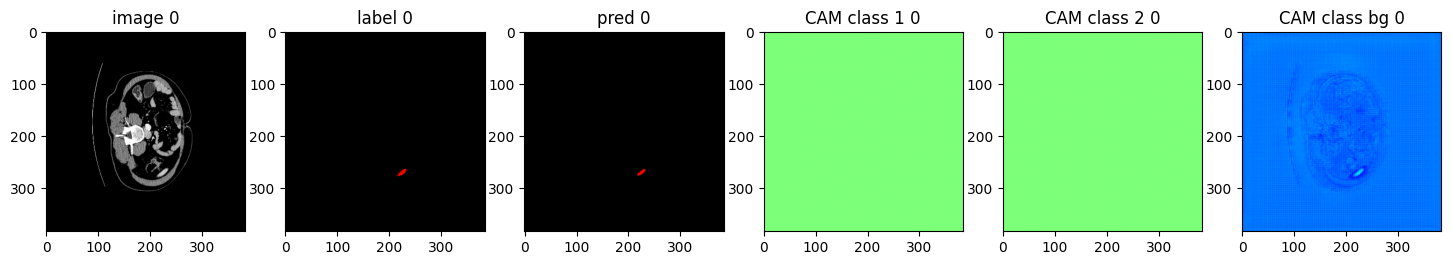

100%|██████████| 32/32 [00:00<00:00, 75.72it/s] 


torch.Size([1, 3, 384, 384, 384])
metatensor(1.)
metatensor(2)


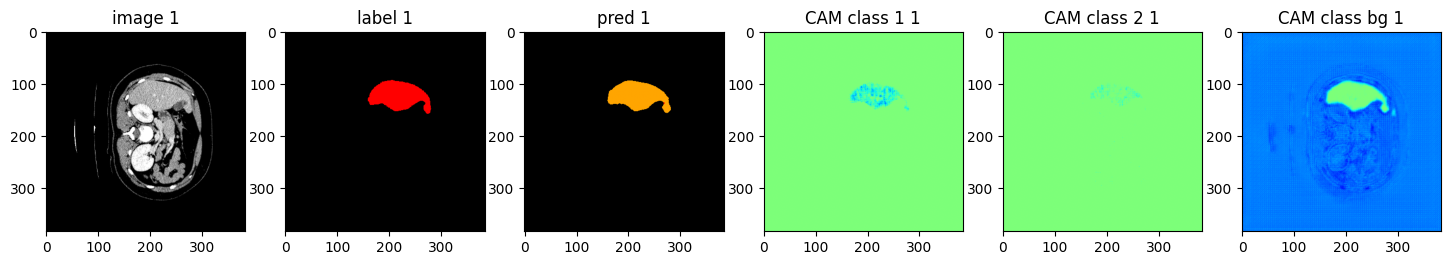

100%|██████████| 32/32 [00:00<00:00, 67.32it/s] 


torch.Size([1, 3, 384, 384, 384])
metatensor(2.)
metatensor(2)


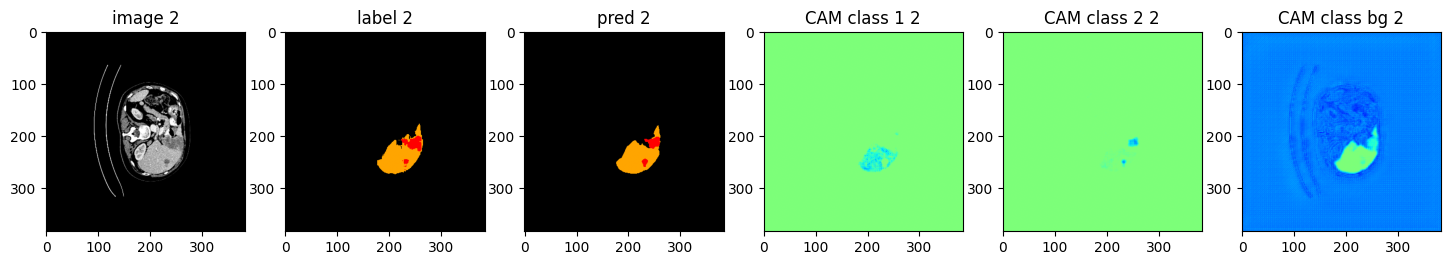

In [29]:
from monai.visualize import GradCAM
import matplotlib.colors as mcolors
# model_2d = seresnet50(spatial_dims=2, in_channels=3, num_classes=4)
cam = GradCAM(nn_module=model, target_layers="model.2.0.conv")
colors = ['black', 'orange', 'red']
cmap = mcolors.ListedColormap(colors)
# with torch.no_grad():
for i, val_data in enumerate(val_loader):
    with torch.no_grad():
        roi_size = (96,96,96)
        sw_batch_size = 4
        val_outputs = sliding_window_inference(val_data["image"].to(device), roi_size, sw_batch_size, model, progress=True)
    print(val_outputs.shape)
        # plot the slice [:, :, 80]
    plt.figure("check", (18, 6))
    plt.subplot(1, 6, 1)
    plt.title(f"image {i}")
    plt.imshow(val_data["image"][0, 0, :, :, 192], cmap="gray")
    plt.subplot(1, 6, 2)
    plt.title(f"label {i}")
    plt.imshow(val_data["label"][0, 0, :, :, 192], cmap=cmap)
    print(val_data["label"][0, 0, :, :, 192].max())
    plt.subplot(1, 6, 3)
    plt.title(f"pred {i}")
    # print(torch.argmax(val_outputs, dim=1).detach().cpu())
    # print(torch.argmax(val_outputs, dim=1).detach().cpu()[0, :, :, 192])
    pred = torch.argmax(val_outputs, dim=1).detach().cpu()
    
    plt.imshow(pred[0, :, :, 192],cmap=cmap)
    print(pred[0,:,:,192].max())
    # print(val_outputs.shape)
    # cams
    plt.subplot(1, 6, 4)
    plt.title(f"CAM class 1 {i}")
    result1 = cam(x= val_data["image"].to(device),class_idx=1)
    plt.imshow(result1[0, 0, :, :, 192].detach().cpu(),cmap="jet", vmin=0, vmax=2)
    # plt.colorbar(im)
    # print(result)
    plt.subplot(1, 6, 5)
    plt.title(f"CAM class 2 {i}")
    result2 = cam(x= val_data["image"].to(device),class_idx=2)
    im_2 = plt.imshow(result2[0, 0, :, :, 192].detach().cpu(),cmap="jet", vmin=0, vmax=2)
    # plt.colorbar(im_2)
    plt.subplot(1, 6, 6)
    plt.title(f"CAM class bg {i}")
    result_bg = cam(x= val_data["image"].to(device),class_idx=0)
    im = plt.imshow(result_bg[0, 0, :, :, 192].detach().cpu(),cmap="jet", vmin=0, vmax=2)
    
    # im = plt.imshow(cam_img, cmap="jet")
    # plt.colorbar(im)
    plt.show()
    if i == 2:
        break